In [22]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.special import erfc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from helper_functions import protocols
from scipy.optimize import curve_fit
import math

## cs

In [38]:
def phase_diffused_cs(sigma, num_samples):
    alphas = np.linspace(0,1,20)
    p_err = np.zeros((len(alphas)))
    for i in range(len(alphas)):
        phis = np.random.normal(0, sigma, size=num_samples)
        wrong_sign_counter = 0

        for phi in phis:
            coherent_sign = np.random.choice([1, -1])
            prog = sf.Program(1)
            with prog.context as q:
                Dgate(coherent_sign*alphas[i]) | q
                Rgate(phi) | q
                MeasureHomodyne(0) | q

            eng = sf.Engine("gaussian")
            result = eng.run(prog)
            result_sign = np.sign(result.samples[0][0])

            if (result_sign>=0 and coherent_sign<0) or (result_sign<0 and coherent_sign>0):
                    wrong_sign_counter+= 1
            p_err[i] = wrong_sign_counter/num_samples
    return p_err

        
    

In [ ]:
sigmas = np.linspace(0, 1, 4)
sigmas_list = []
num_samples = 2000
for i, sigma in enumerate(sigmas):
    sigmas_list.append(phase_diffused_cs(sigma, num_samples))
    print(f"\rProgress: {i+1}/{len(sigmas)}", end="", flush=True)

Progress: 4/4

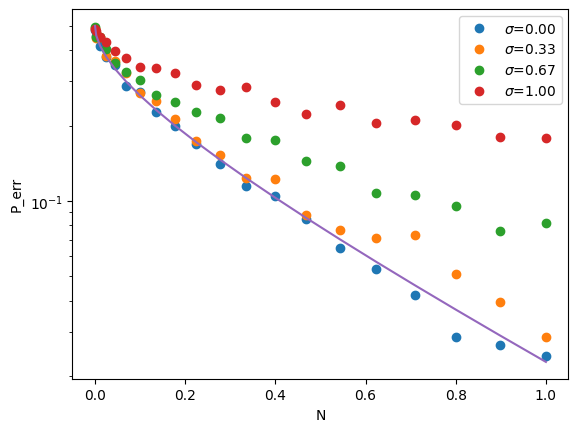

In [20]:
alphas = np.linspace(0,1,20)
N = alphas**2
for i, p_err in enumerate(sigmas_list):
    plt.plot(N, p_err, 'o', label = fr'$\sigma$={sigmas[i]:.2f}')
plt.xlabel('N')
plt.ylabel('P_err')
plt.plot(N, protocols.perr_homodyne(alphas**2, 0))
plt.yscale('log')
plt.legend()

## DSS

In [58]:
def phase_diffused_dss(N_grid:np.array, beta_grid:np.array, sigma, num_samples:int):

    #Calculation of error probability
    #============================================
    p_err = np.zeros((len(N_grid), len(beta_grid)))
    
    for i,N in enumerate(N_grid):
        alphas = np.sqrt(N*(1-beta_grid)) 
        print(f"\rProgress: {i+1}/{len(N_grid)}", end="", flush=True)
        
        for k, beta in enumerate(beta_grid):
            wrong_sign_counter = 0
            r_s = math.asinh(np.sqrt(N*beta))
            phis = np.random.normal(0, sigma, size=num_samples)
            for phi in phis:
                coherent_sign = np.random.choice([1, -1])
                prog = sf.Program(1)
                with prog.context as q:
                    Sgate(r_s, 0) | q[0] 
                    Dgate(coherent_sign*alphas[k]) | q
                    Rgate(phi) | q
                    MeasureHomodyne(0) | q

                eng = sf.Engine("gaussian")
                result = eng.run(prog)
                result_sign = np.sign(result.samples[0][0])

                if (result_sign>=0 and coherent_sign<0) or (result_sign<0 and coherent_sign>0):
                        wrong_sign_counter+= 1
                p_err[i][k] = wrong_sign_counter/num_samples
    return p_err

In [59]:
# Parameters
N = np.linspace(0, 2.0, 20)
beta = np.linspace(0.0, 1.0, 20)

sigma = 0.1
num_samples = 2000

# Compute error probabilities
P_err = phase_diffused_dss(N, beta, sigma, num_samples)

# Create meshgrid for plotting
N_grid, beta_grid = np.meshgrid(N, beta, indexing="ij")


Progress: 20/20

In [61]:
import plotly.graph_objects as go
import numpy as np

# Flatten grid for scatter points
N_grid, beta_grid = np.meshgrid(N, beta, indexing="ij")

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=N_grid.ravel(),
        y=beta_grid.ravel(),
        z=P_err.ravel(),
        mode="markers",
        marker=dict(
            size=4,
            color=P_err.ravel(),
            colorscale="Viridis",
            colorbar=dict(title=r"P_err"),
            opacity=0.8
        ),
        name="Simulation"
    )
)

fig.update_layout(
    title=rf"Phase-diffused DSS ($\sigma={sigma}$)",
    scene=dict(
        xaxis_title="N",
        yaxis_title=r"β",
        zaxis=dict(title="P_err", type='log')
    ),
    width=900,
    height=800
)

fig.show()